# Exploratory Data Analysis (EDA)

## Objective
The goal of this analysis is to:
- Understand the dataset structure
- Identify key patterns and relationships
- Detect data quality issues (missing values, outliers)
- Generate hypotheses for further research

## Data Loading & Setup
We begin by importing necessary libraries and loading the dataset.

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = pd.read_csv('../data/raw/telco_churn.csv')

## Dataset Overview
In this section, we explore the basic structure of the dataset, including the number of observations, features, and data types.

In [6]:
# Display first rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Shape of the dataset (rows, columns)
print("Dataset shape:", df.shape)

Dataset shape: (7043, 21)


In [8]:
# Column names
print("Columns:")
print(df.columns.tolist())

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [9]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
# Summary statistics for numerical features
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
# Summary statistics for categorical features
df.describe(include=['object', 'category'])

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


- The dataset contains 7043 rows and 21 columns  
- There are both numerical and categorical features  
- Columns don't contain missing values  

## Data Types & Feature Description
We examine the types of features (numerical and categorical) and provide a brief description of each variable.

In [14]:
# Separate numerical and categorical columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical features: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [15]:
# Create a summary table with data types
feature_summary = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': df.dtypes.values
})

feature_summary

,Feature,Data Type
0,customerID,object
1,gender,object
2,SeniorCitizen,int64
3,Partner,object
4,Dependents,object
5,tenure,int64
6,PhoneService,object
7,MultipleLines,object
8,InternetService,object
9,OnlineSecurity,object


In [16]:
# Add number of unique values per feature
feature_summary['Unique Values'] = df.nunique().values

feature_summary

,Feature,Data Type,Unique Values
0,customerID,object,7043
1,gender,object,2
2,SeniorCitizen,int64,2
3,Partner,object,2
4,Dependents,object,2
5,tenure,int64,73
6,PhoneService,object,2
7,MultipleLines,object,3
8,InternetService,object,3
9,OnlineSecurity,object,3


In [17]:
# 1. Convert TotalCharges to numeric, turning empty strings / spaces into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Check how many missing values appeared after the conversion
print("Number of missing values in TotalCharges after conversion:", 
      df['TotalCharges'].isna().sum())

Number of missing values in TotalCharges after conversion: 11


#### Numerical Features
- **SeniorCitizen** (`int64`)  
  Binary flag: 1 = customer is a senior citizen, 0 = not a senior citizen
- **tenure** (`int64`)  
  Number of months the customer has been with the company
- **MonthlyCharges** (`float64`)  
  Current monthly recurring charge (in currency units)
- **TotalCharges** (`object` → converted to `float64`)  
  Total amount billed to the customer since the start of the contract  
  *Note: This feature was originally read as string (`object`) due to some empty values stored as spaces (" "). It was converted to numeric using `pd.to_numeric(..., errors='coerce')`. As a result, **11 missing values (NaN)** appeared in the dataset. Handling of these missing values will be performed in the next section (Missing Values Analysis).*

#### Categorical Features
- **customerID** (`object`)  
  Unique identifier for each customer (not used for modeling)
- **gender** (`object`)  
  Customer's gender: Male / Female
- **Partner** (`object`)  
  Whether the customer has a partner: Yes / No
- **Dependents** (`object`)  
  Whether the customer has dependents: Yes / No
- **PhoneService** (`object`)  
  Whether the customer subscribes to home phone service: Yes / No
- **MultipleLines** (`object`)  
  Whether the customer has multiple phone lines: Yes / No / No phone service
- **InternetService** (`object`)  
  Type of internet service: DSL / Fiber optic / No
- **OnlineSecurity** (`object`)  
  Online security add-on: Yes / No / No internet service
- **OnlineBackup** (`object`)  
  Online backup add-on: Yes / No / No internet service
- **DeviceProtection** (`object`)  
  Device protection add-on: Yes / No / No internet service
- **TechSupport** (`object`)  
  Technical support add-on: Yes / No / No internet service
- **StreamingTV** (`object`)  
  TV streaming service add-on: Yes / No / No internet service
- **StreamingMovies** (`object`)  
  Movie streaming service add-on: Yes / No / No internet service
- **Contract** (`object`)  
  Contract duration: Month-to-month / One year / Two year
- **PaperlessBilling** (`object`)  
  Whether the customer uses paperless billing: Yes / No
- **PaymentMethod** (`object`)  
  Payment method used: Electronic check / Mailed check / Bank transfer (automatic) / Credit card (automatic)
- **Churn** (`object`)  
  **Target variable** — Whether the customer churned: Yes / No

## Target Variable Analysis
We analyze the distribution of the target variable to understand class balance and potential modeling challenges.

In [20]:
# Value counts
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [21]:
# Value counts (normalized)
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

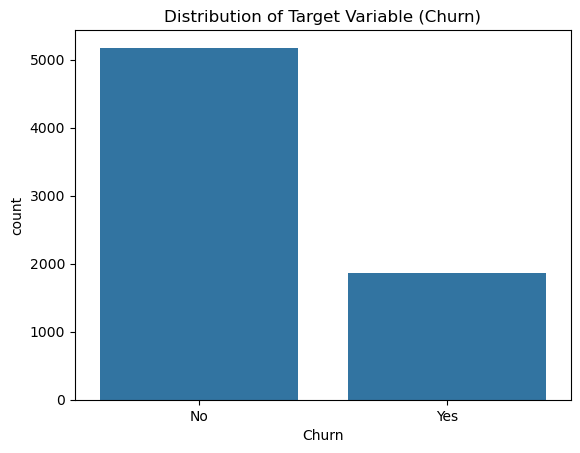

In [22]:
# Distribution of Target Variable 
sns.countplot(x='Churn', data=df)
plt.title("Distribution of Target Variable (Churn)")
plt.show()

The dataset shows a moderate class imbalance (73% vs 27%), which makes accuracy an unreliable evaluation metric.

Instead, more appropriate metrics such as recall, F1-score, and ROC-AUC will be used, as they better reflect model performance on the minority class (churned customers).

## Missing Values Analysis
This section focuses on identifying missing values and understanding their distribution across the dataset.

In [25]:
# Total number of missing values per column
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

TotalCharges    11
dtype: int64

In [26]:
# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent[missing_percent > 0].sort_values(ascending=False)

TotalCharges    0.156183
dtype: float64

The dataset contains a small number of missing values.

- The TotalCharges column has 11 missing values after conversion to numeric format  
- These missing values account for a very small fraction of the dataset  

Overall, the amount of missing data is negligible and is unlikely to significantly impact the analysis.  
Missing values will be handled during the preprocessing stage.

## Numerical Features Analysis
We analyze numerical features to understand their distributions, detect outliers, and identify potential anomalies.

In [29]:
# Select numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
numerical_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [30]:
# Summary statistics
df[numerical_features].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


**Key Takeaways:**

- **SeniorCitizen**: ~16% of customers  
- **tenure**: Avg ~32 months, slightly right-skewed  
- **MonthlyCharges**: Avg ~$65, moderate spread  
- **TotalCharges**: High variability; 11 missing values after conversion  

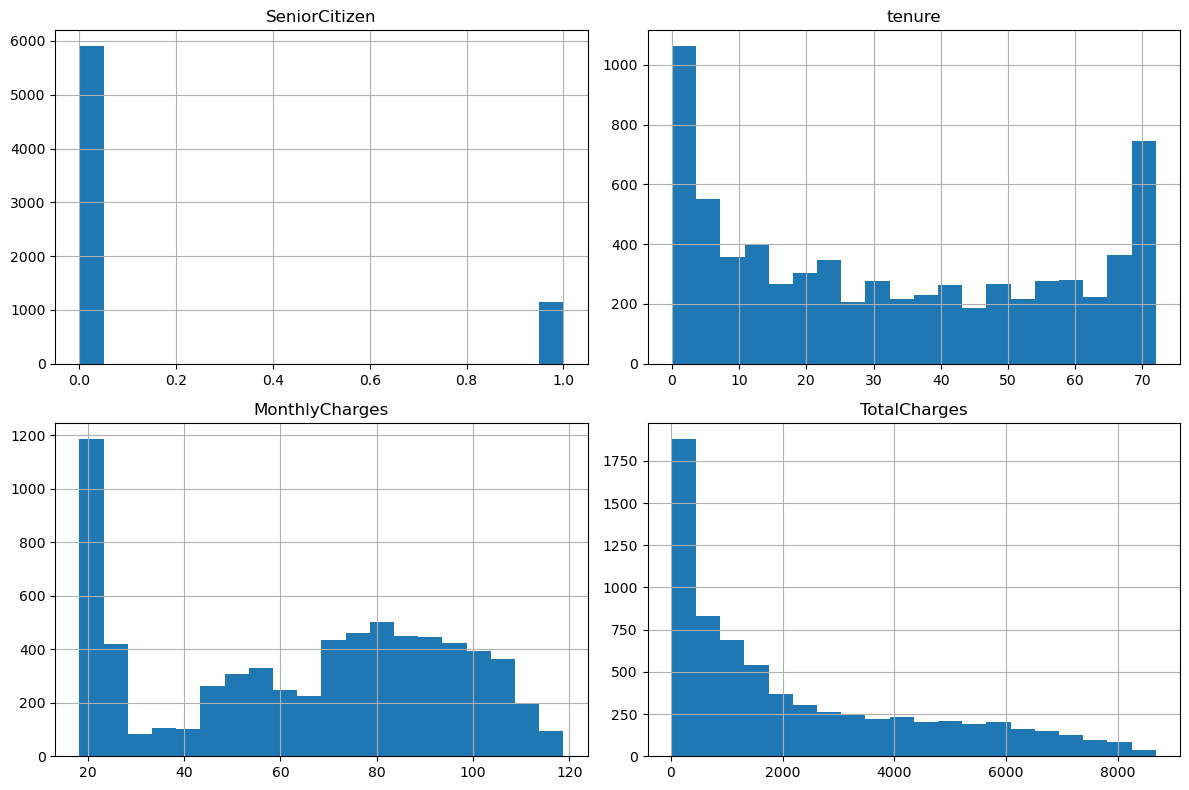

In [32]:
# Histograms
df[numerical_features].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

**Observations from Histograms:**

- **SeniorCitizen**: Highly imbalanced (mostly 0)  
- **tenure**: Right-skewed, many customers with low tenure → potential higher churn among new users  
- **MonthlyCharges**: Bimodal distribution (~20–25 and ~80–110)  
- **TotalCharges**: Strongly right-skewed with a long tail  

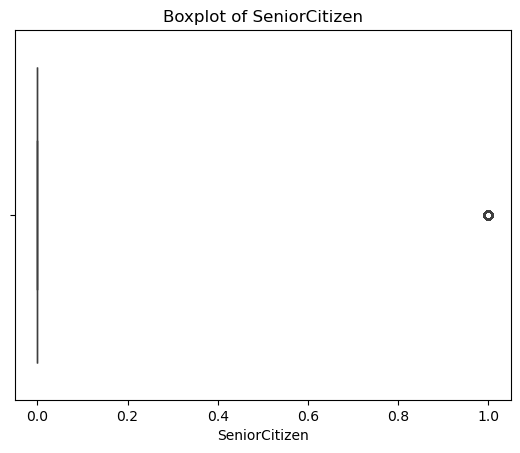

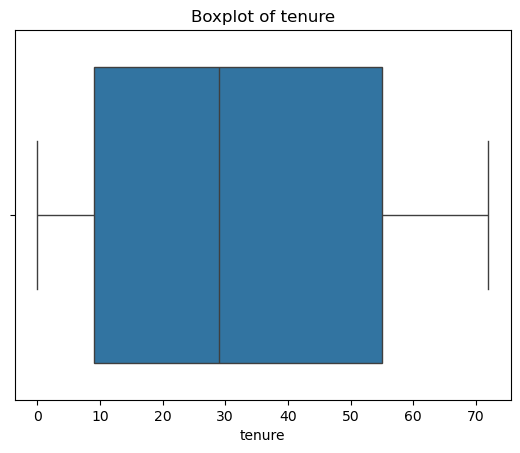

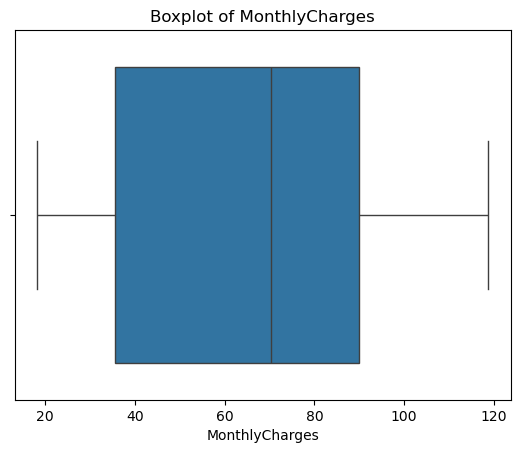

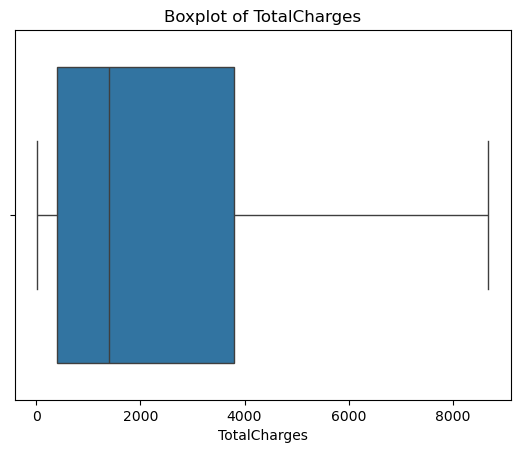

In [34]:
# Boxplots for detecting outliers
for col in numerical_features:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**Summary of Numerical Features**

Numerical features show meaningful distribution patterns without critical data issues.

- Several features (tenure, TotalCharges) are right-skewed, indicating many new customers and fewer long-term ones  
- No significant outliers were detected; extreme values appear to be valid  

Overall, numerical features are well-behaved and suitable for further analysis and modeling.

## Categorical Features Analysis
We explore categorical variables to understand their value distributions and identify dominant or rare categories.

In [37]:
# Select categorical features
categorical_features = df.select_dtypes(include=['object', 'category', 'bool']).columns
categorical_features

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [38]:
# Normalized value counts (proportions)
for col in categorical_features:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(normalize=True))


Column: customerID
customerID
7590-VHVEG    0.000142
3791-LGQCY    0.000142
6008-NAIXK    0.000142
5956-YHHRX    0.000142
5365-LLFYV    0.000142
                ...   
9796-MVYXX    0.000142
2637-FKFSY    0.000142
1552-AAGRX    0.000142
4304-TSPVK    0.000142
3186-AJIEK    0.000142
Name: proportion, Length: 7043, dtype: float64

Column: gender
gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64

Column: Partner
Partner
No     0.516967
Yes    0.483033
Name: proportion, dtype: float64

Column: Dependents
Dependents
No     0.700412
Yes    0.299588
Name: proportion, dtype: float64

Column: PhoneService
PhoneService
Yes    0.903166
No     0.096834
Name: proportion, dtype: float64

Column: MultipleLines
MultipleLines
No                  0.481329
Yes                 0.421837
No phone service    0.096834
Name: proportion, dtype: float64

Column: InternetService
InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, d

The table below shows the normalized value counts (proportions) for each categorical feature:

- **customerID**: 7043 unique values → each customer appears exactly once (0.0142% each). Used only as identifier, not for modeling.
- **gender**: Almost perfectly balanced  
  Male: 50.5% | Female: 49.5%
- **Partner**: Slightly more customers without partner  
  No: 51.7% | Yes: 48.3%
- **Dependents**: Strongly skewed — most customers have no dependents  
  No: 70.0% | Yes: 30.0%
- **PhoneService**: Very dominant — almost all customers have phone service  
  Yes: 90.3% | No: 9.7%
- **MultipleLines**: Among phone users, "No" and "Yes" are close; ~9.7% have no phone service  
  No: 48.1% | Yes: 42.2% | No phone service: 9.7%
- **InternetService**: Fiber optic is the most popular internet type  
  Fiber optic: 44.0% | DSL: 34.4% | No: 21.7%
- **OnlineSecurity / TechSupport**: "No" is dominant among internet users  
  No: ~49–50% | Yes: ~29% | No internet service: 21.7%
- **OnlineBackup / DeviceProtection**: More balanced, but "No" still leads slightly  
  No: ~43–44% | Yes: ~34–35% | No internet service: 21.7%
- **StreamingTV / StreamingMovies**: Very close to 50/50 split among internet users  
  No: ~39–40% | Yes: ~38–39% | No internet service: 21.7%
- **Contract**: Month-to-month dominates → high flexibility, but also high churn risk  
  Month-to-month: 55.0% | Two year: 24.1% | One year: 20.9%
- **PaperlessBilling**: Majority prefer paperless  
  Yes: 59.2% | No: 40.8%
- **PaymentMethod**: Electronic check is the most common (and often linked to higher churn)  
  Electronic check: 33.6% | Mailed check: 22.9% | Bank transfer (auto): 21.9% | Credit card (auto): 21.6%
- **Churn** (target): Moderate imbalance — typical for churn datasets  
  No (stayed): 73.5% | Yes (churned): 26.5%

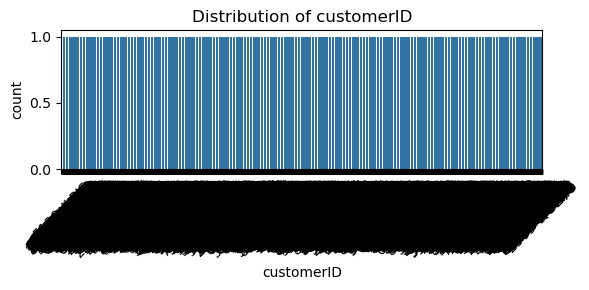

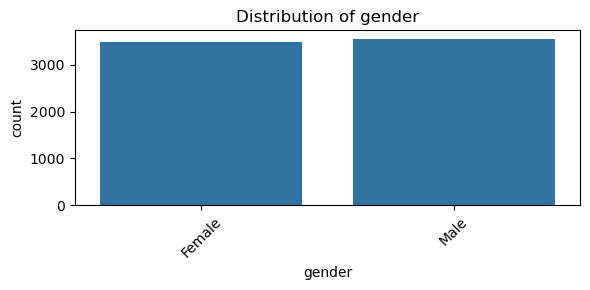

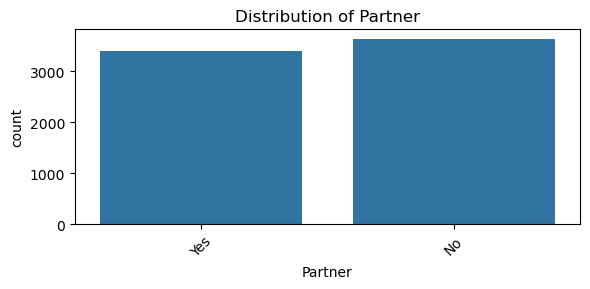

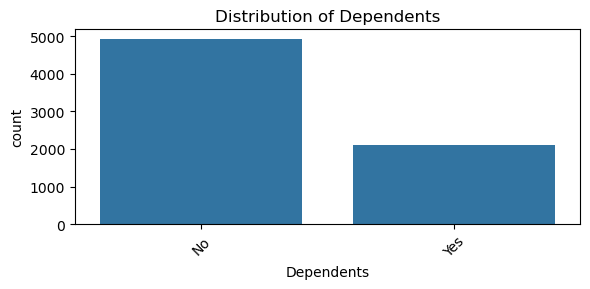

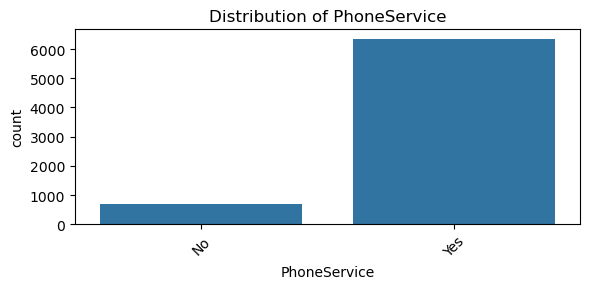

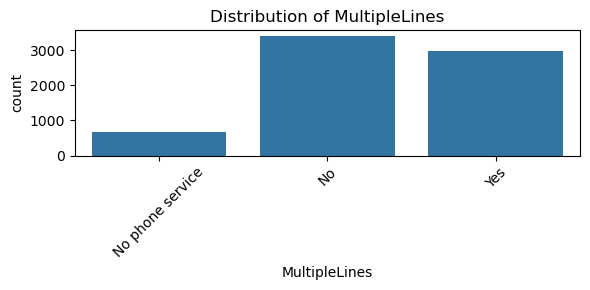

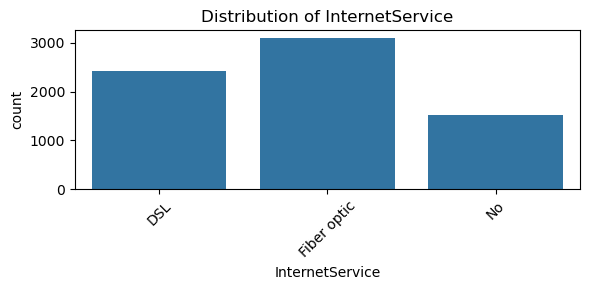

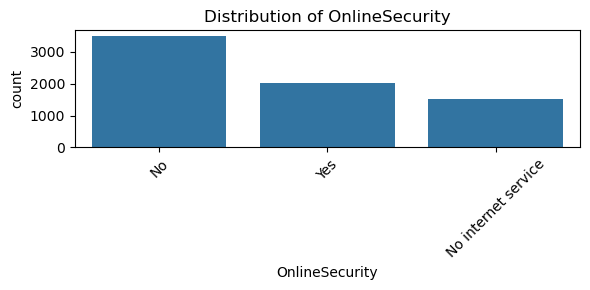

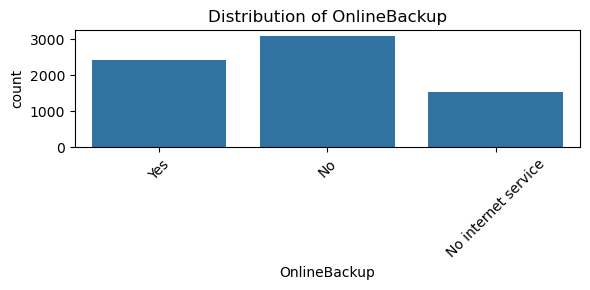

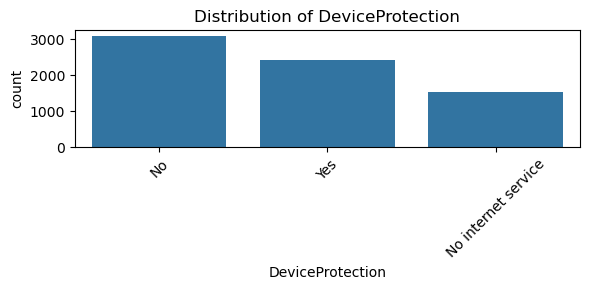

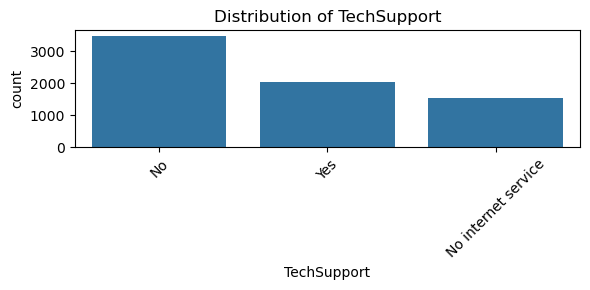

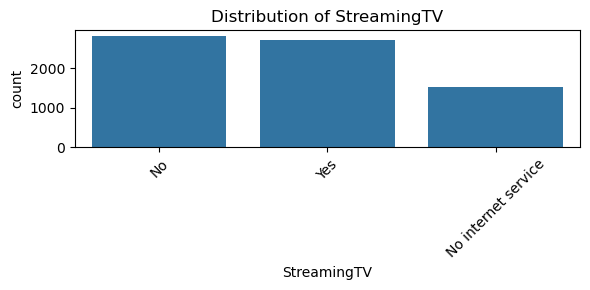

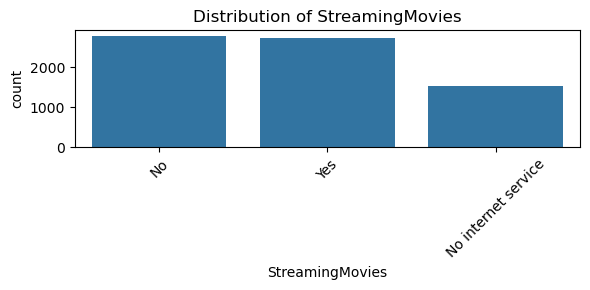

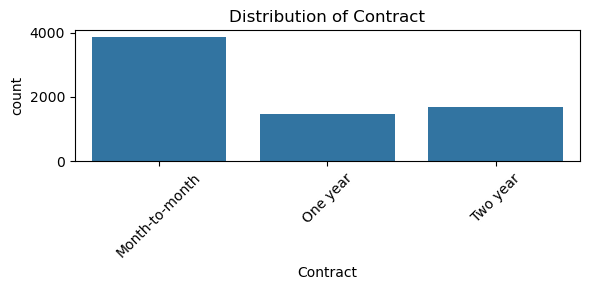

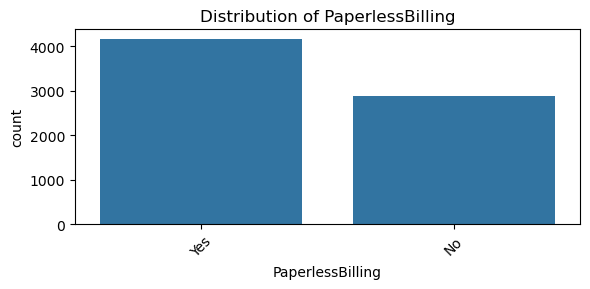

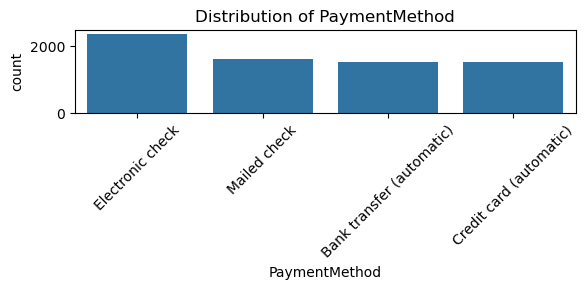

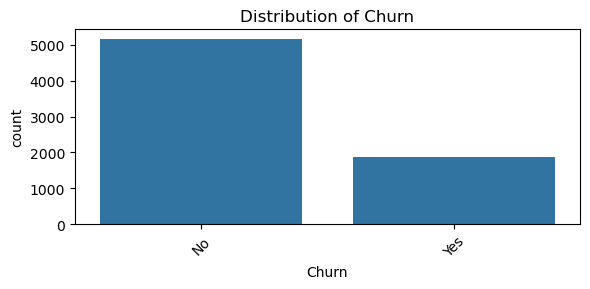

In [40]:
# Count plots
import matplotlib.pyplot as plt
import seaborn as sns

for col in categorical_features:
    plt.figure(figsize=(6, 3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The count plots confirm the following patterns:

- **gender**, **Partner** — nearly balanced → no strong dominance.
- **Dependents**, **PhoneService** — highly skewed (most customers have no dependents and do have phone service).
- **InternetService** → Fiber optic slightly ahead of DSL; ~22% have no internet.
- **Add-on services** (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport) → "No" is the most frequent choice among internet users.
- **StreamingTV** and **StreamingMovies** → almost equal split between Yes/No (among those with internet).
- **Contract** → Month-to-month is by far the largest group (~55%).
- **PaperlessBilling** → clear majority uses paperless.
- **PaymentMethod** → Electronic check stands out as the single most popular method.
- **Churn** → ~73.5% of customers stayed (No), ~26.5% left (Yes) → class imbalance to consider during modeling.

**Summary**
- **High concentration in Month-to-month contracts** (55%) → these customers are usually at much higher churn risk.
- **Fiber optic** is the most popular internet type → often associated with higher monthly charges and potentially higher churn.
- **Low adoption of protective add-ons** (OnlineSecurity, TechSupport, DeviceProtection ~29%) → opportunity to increase uptake and reduce churn.
- **Streaming services** are adopted by roughly 38–39% of internet users → moderate penetration.
- **Electronic check** dominates payment methods (33.6%) → historically one of the strongest predictors of churn in this dataset.
- **Very few customers without phone service** (9.7%) → most are either phone-only or combined services.
- **Target variable Churn** shows moderate imbalance (73.5% / 26.5%) → we will use stratified splitting, class weights or resampling techniques in modeling.

**Next steps:**
- Encode categorical features (one-hot / target encoding / ordinal where appropriate).
- Proceed to bivariate analysis (churn vs each categorical feature).

## Feature Relationships
In this section, we investigate relationships between features and their impact on the target variable.

### Numerical Features Correlation

In [45]:
# Select numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

In [46]:
# Correlation matrix
corr_matrix = df[numerical_features].corr()
corr_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


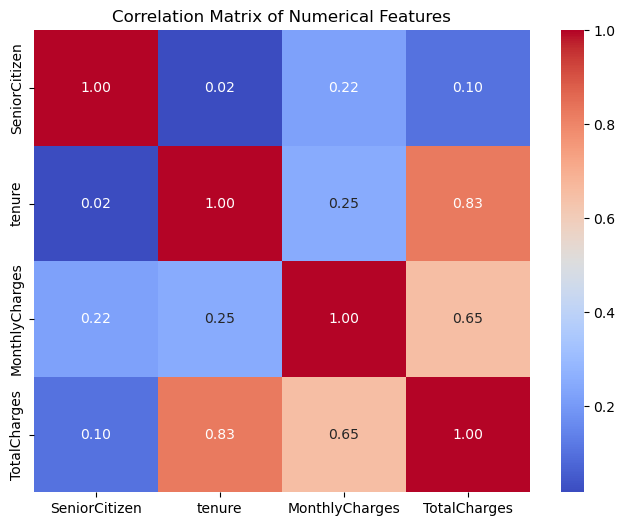

In [47]:
# Heatmap of correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

Key Observations from the Correlation Matrix

Very strong positive correlation between tenure and TotalCharges (r = 0.83)
- This is expected: the longer a customer stays, the more they accumulate in total charges.
- Implication: TotalCharges is largely redundant with tenure — we may consider dropping one of them or using only one in modeling to avoid multicollinearity.
Moderate positive correlation between MonthlyCharges and TotalCharges (r = 0.65)
- Higher monthly bills naturally lead to higher cumulative charges over time.
Moderate positive correlation between MonthlyCharges and tenure (r = 0.25)
- Slightly higher monthly charges are associated with longer-tenure customers (possibly due to more add-on services accumulated over time).
Weak positive correlation between SeniorCitizen and MonthlyCharges (r = 0.22)
- Senior citizens tend to have slightly higher monthly bills (possibly different service bundles or less price sensitivity).
Very weak correlations involving SeniorCitizen with tenure and TotalCharges (r ≈ 0.02–0.10)
- Being a senior citizen has almost no linear relationship with how long customers stay or how much they accumulate in charges.

Main Conclusions & Modeling Implications

High multicollinearity exists between tenure and TotalCharges (0.83).
- In linear models (Logistic Regression, etc.), this can cause instability in coefficients.
- Recommendation: keep tenure (more interpretable and direct) and consider dropping TotalCharges, or use feature selection / regularization (Lasso/Ridge).
MonthlyCharges shows moderate relationships with both tenure and total charges — it captures pricing behavior somewhat independently.
SeniorCitizen is relatively independent from the other numerical features → it can provide unique information when combined with categorical features.
These correlations only capture linear relationships among numerical features.

### Categorical Features vs Target

In [50]:
# Select categorical features
categorical_features = df.select_dtypes(include=['object', 'category', 'bool']).columns
categorical_features = [col for col in categorical_features if col != 'Churn']

C:\Users\isazo\AppData\Local\Temp\ipykernel_13300\2251224199.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\isazo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


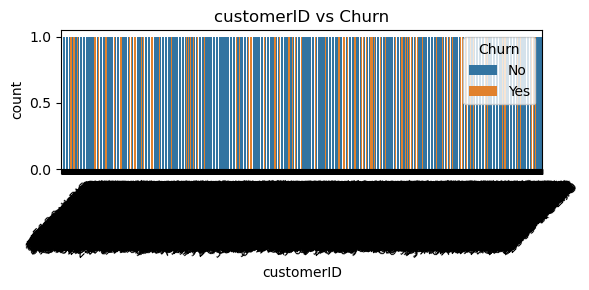

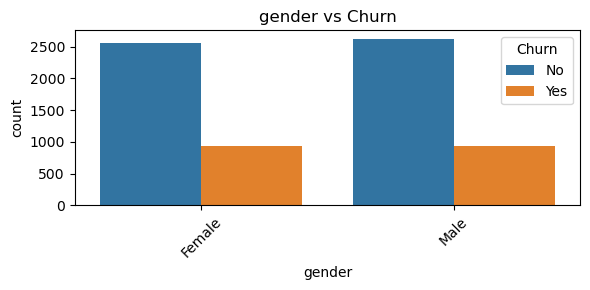

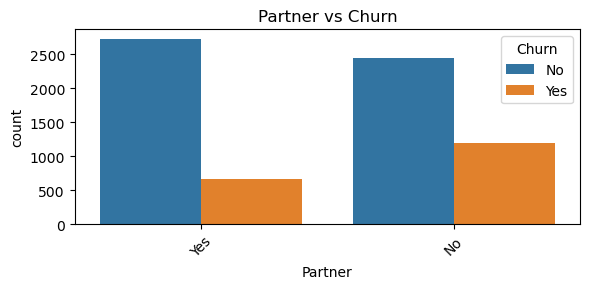

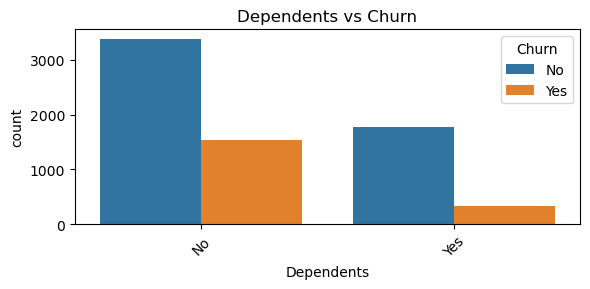

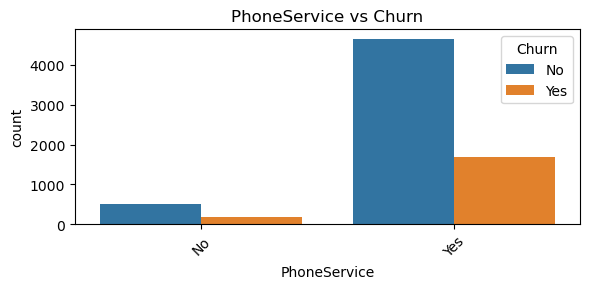

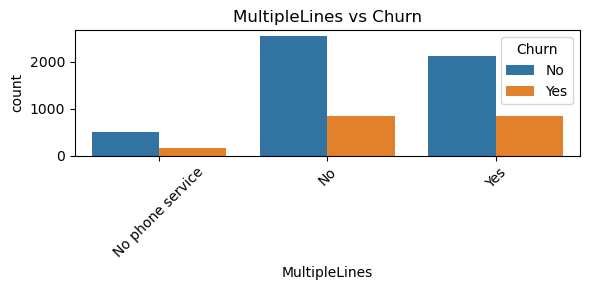

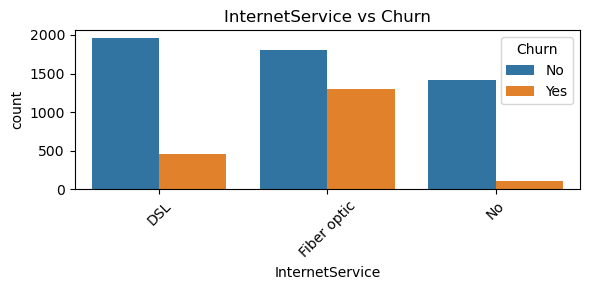

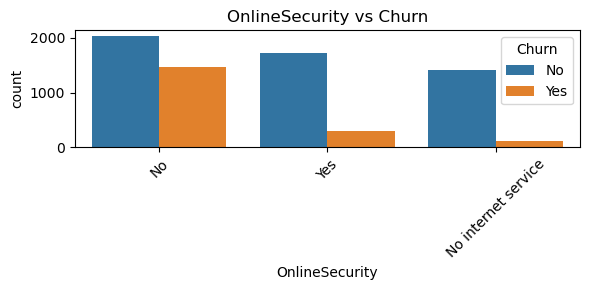

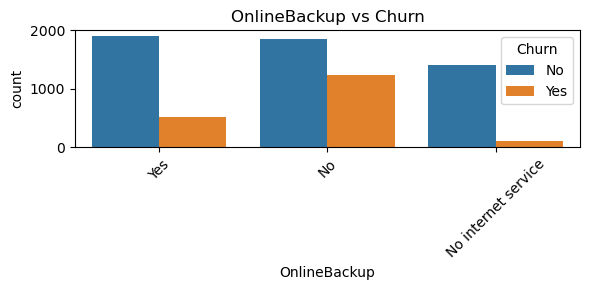

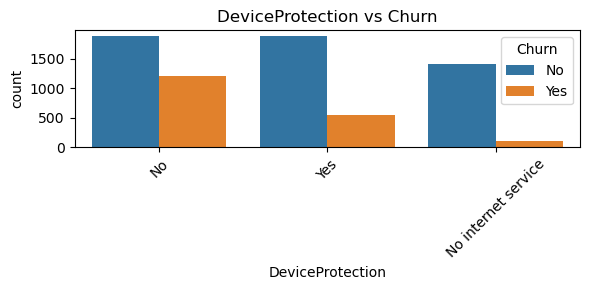

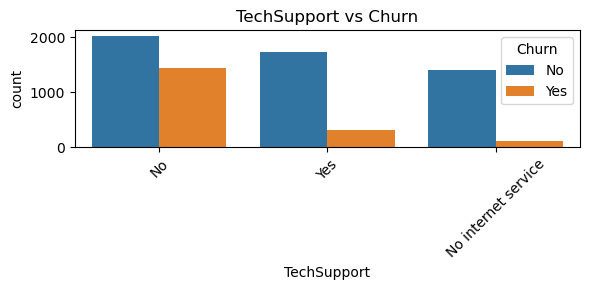

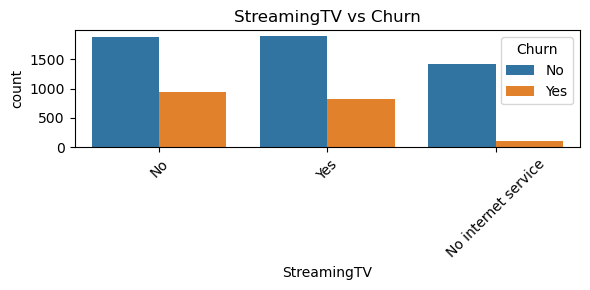

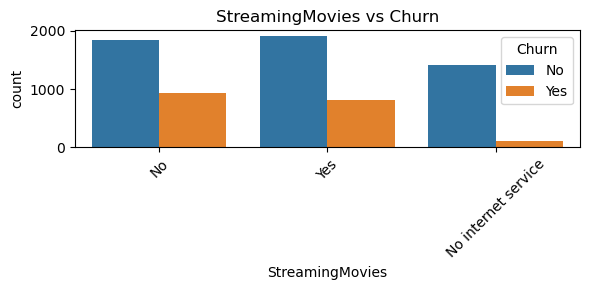

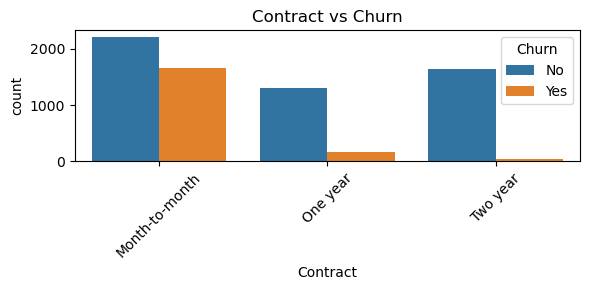

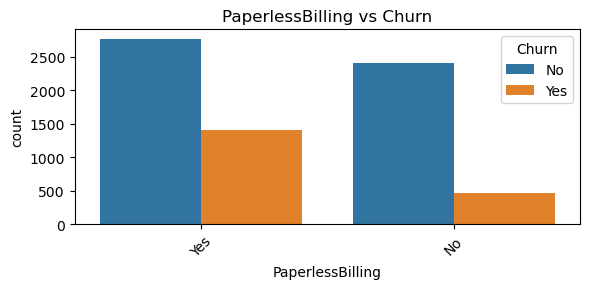

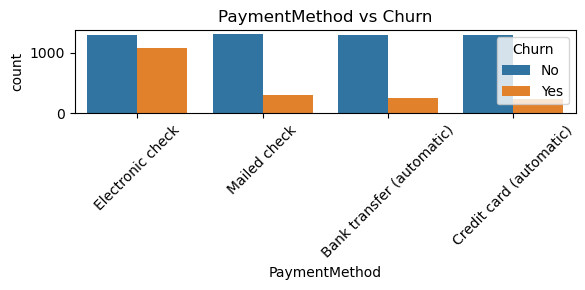

In [51]:
# Count plots with target (Churn)
import matplotlib.pyplot as plt
import seaborn as sns

for col in categorical_features:
    plt.figure(figsize=(6, 3))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The following plots show the distribution of each categorical feature split by Churn (No = stayed, Yes = churned):

- **customerID** — uniform distribution (each ID unique), no meaningful pattern.
- **gender** — very similar churn rates between Male and Female (~26–27% in both groups) → gender has almost no predictive power.
- **Partner** — Customers **without a partner** (No) show noticeably higher churn than those with a partner (Yes).
- **Dependents** — Customers **without dependents** (No) have significantly higher churn than those with dependents (Yes).
- **PhoneService** — Customers with phone service (Yes) have higher absolute churn numbers (due to much larger group size), but churn rate is similar or slightly higher than No.
- **MultipleLines** — Among phone users, those with **MultipleLines = Yes** tend to churn slightly more than No; No phone service has very low churn.
- **InternetService** — **Fiber optic** users have the highest churn (both absolute and rate), DSL is moderate, **No internet service** has very low churn.
- **OnlineSecurity** — Customers with **OnlineSecurity = Yes** show dramatically lower churn; **No** has high churn; No internet service — very low.
- **OnlineBackup** — Similar pattern: **Yes** → much lower churn; **No** → high churn.
- **DeviceProtection** — **Yes** reduces churn noticeably; **No** increases it.
- **TechSupport** — One of the strongest protectors: **TechSupport = Yes** → very low churn; **No** → high churn.
- **StreamingTV / StreamingMovies** — Customers with these services (Yes) churn **slightly more** than No (among internet users); the difference is moderate.
- **Contract** — Extremely strong signal:  
  - **Month-to-month** → very high churn (~42–50%)  
  - **One year** → moderate  
  - **Two year** → extremely low churn (~3–5%)
- **PaperlessBilling** — Customers using **paperless billing (Yes)** churn more than those who don't.
- **PaymentMethod** — **Electronic check** has by far the highest churn rate; automatic payments (Bank transfer / Credit card) and Mailed check show much lower churn.


The plots reveal several clear patterns and strong predictors of churn:

1. **Contract type is the strongest single predictor**  
   Month-to-month contracts have dramatically higher churn than 1- or 2-year contracts.

2. **Add-on protection services strongly reduce churn**  
   - OnlineSecurity, TechSupport, DeviceProtection, OnlineBackup  
   → Customers who have these services are much less likely to leave.

3. **Internet service type matters a lot**  
   Fiber optic → highest churn (possibly due to higher price + expectations)  
   No internet service → very loyal customers.

4. **Demographic & family factors**  
   - No Partner / No Dependents → higher churn (customers may be more "footloose").  
   - Gender → no meaningful difference.

5. **Billing & payment behavior**  
   - PaperlessBilling = Yes → higher churn (possibly younger/more digital-savvy but less loyal).  
   - PaymentMethod = Electronic check → strongest churn signal among payment types (convenience but low commitment?).

6. **Streaming services have mixed / weak effect**  
   StreamingTV and StreamingMovies slightly increase churn (perhaps associated with higher bills or less essential).


- **Top predictors to prioritize**: Contract, InternetService, TechSupport, OnlineSecurity, PaymentMethod, Partner, Dependents.
- **Feature engineering ideas**:
  - Binary flags for having protection add-ons (OnlineSecurity + TechSupport + DeviceProtection + OnlineBackup).
  - Group PaymentMethod into "Automatic" vs "Manual".
  - Bin tenure (already numerical) and combine with Contract.
- **Business recommendations**:
  - Push customers toward longer contracts (1- or 2-year) with discounts/incentives.
  - Aggressively promote OnlineSecurity, TechSupport, and DeviceProtection bundles — they act as strong "retention anchors".
  - Reconsider incentives for Electronic check users or encourage switching to automatic payments.
  - Target new customers (low tenure + month-to-month + no add-ons) with proactive retention campaigns.


### Numerical Features vs Target

In [54]:
# Select numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

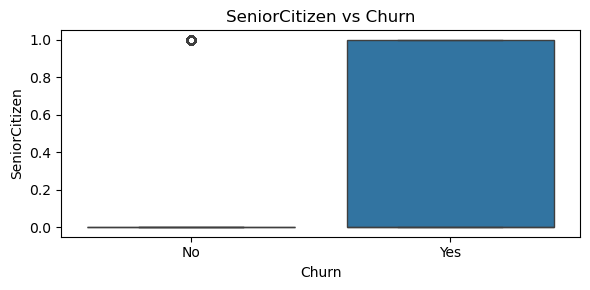

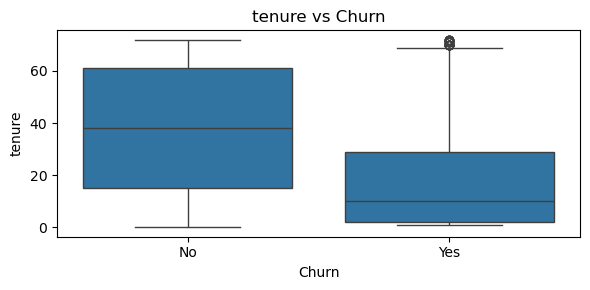

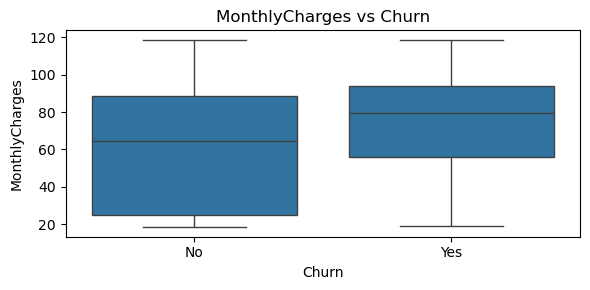

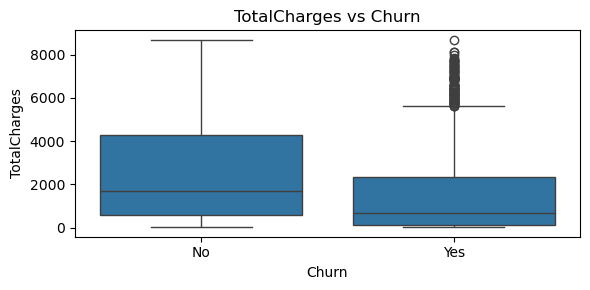

In [55]:
for col in numerical_features:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.tight_layout()
    plt.show()

**Observations:**

- **SeniorCitizen**: Churn is higher among senior citizens, although the feature is binary and imbalanced  
- **tenure**: Customers with low tenure are significantly more likely to churn, while long-term customers tend to stay  
- **MonthlyCharges**: Higher monthly charges are associated with increased churn  
- **TotalCharges**: Customers with lower total charges tend to churn more, likely due to shorter tenure  

Overall, churn is strongly associated with newer customers and those paying higher monthly fees.

## Key Insights & Hypotheses

- The dataset shows a moderate class imbalance (73% vs 27%), which should be considered during modeling  
- Customer tenure is one of the strongest indicators of churn: new customers are significantly more likely to leave  
- Higher MonthlyCharges are associated with increased churn, suggesting price sensitivity  
- TotalCharges is strongly related to tenure and reflects customer lifetime value rather than independent behavior  
- Contract type and service-related features (e.g., internet services) are likely to be strong predictors of churn  
- Most categorical features are low-cardinality, making them suitable for encoding  

**Hypotheses:**

- Customers with short tenure have a higher probability of churn  
- Customers with higher monthly charges are more likely to churn  
- Long-term customers (high tenure, high total charges) are less likely to leave  
- Contract type (e.g., month-to-month) significantly influences churn behavior  

## Summary

The dataset is well-structured and suitable for analysis and modeling.

- Missing values are minimal and limited to the TotalCharges feature  
- Numerical features show meaningful patterns, including skewness and customer segmentation  
- No significant outliers or data quality issues were identified  
- Categorical features exhibit clear distributions and potential relationships with the target variable  
- Several features (e.g., tenure, MonthlyCharges) show strong association with churn  

Overall, the dataset provides a solid foundation for building predictive models.

## Next Steps
Based on the EDA, the following preprocessing steps will be performed:
- Handling missing values
- Encoding categorical variables
- Treating outliers
- Feature scaling
- Feature engineering